# Encoder Embedding Case Study

This notebook is the **primary driver** for the embedding quality assessment pipeline.
All reusable functions live in `encoder_case_study.py`; this notebook handles
configuration, orchestration, and visualisation.

### Analyses included

| # | Analysis | Purpose |
|---|----------|---------|
| 1 | Interface-enrichment statistics | Are interface residues enriched in embedding score? |
| 2 | Embedding-norm separation | Do interface residues have distinct L2 norms? |
| 3 | Embedding norm line plots | Per-residue visualisation of L1/L2/max norms |
| 4 | Cosine similarity heatmaps | Contact-map-style cross-chain similarity |
| 5 | Cross-chain nearest-neighbour precision | Do interface residues' K-NN come from the partner chain? |
| 6 | 2-D embedding scatter (UMAP / t-SNE) | Are chains and interface residues geometrically separable? |
| 7 | Attention score extraction & visualisation | Which residues does the HGT model attend to? |
| 8 | B-factor PDB generation | Colour PDBs by embedding score for PyMOL |

# 1. Setup & Configuration

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re

from encoder_case_study import (
    build_encoder, compute_embeddings, get_interface_mask,
    resolve_target_pdbs, load_esm_embeddings,
    run_comparison, print_results,
    write_bfactor_pdbs, cosine_similarity_matrix, compute_contact_map, embed_2d,
    extract_attention_scores,
)
from utils.Training_modules.common_utils import load_ssl_config

%matplotlib inline
plt.rcParams.update({'font.size': 12})

In [ ]:
# ── user configuration ────────────────────────────────────────────────
PRETRAINED_PATH = '../GraPPI_data/trained_data_ssl_finetune/6layers_10hdim_esm/'
PDB_ROOT        = '../GraPPI_data/curated_db'
PDB_NAMES       = ['6isc', '1us7', '2vn5', '4bi8']   # explicit targets
VAL_RATIO       = 0.01       # fraction of val set to add (0 = off)
CUDA_ID         = 0
DR_METHOD       = 'isomap'     # pca | isomap | umap | tsne
N_SHUFFLE       = 10        # shuffled-control repeats
COMPARE_ESM     = True      # include raw ESM / ESM480 baselines
SEED            = 42
BATCH_SIZE      = 50
OUTPUT_DIR      = os.path.join(PRETRAINED_PATH, 'bfactor_pdbs_dir')

device = torch.device(f'cuda:{CUDA_ID}' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda:0


# 2. Load Graphs & Build Encoders

In [ ]:
ssl_config = load_ssl_config(PRETRAINED_PATH)
emb_type = ssl_config['embedding_type']
print(f"SSL config (GraPPI): {ssl_config['num_layers']} layers, "
      f"hidden_dim=2^{ssl_config['hidden_dim_power']}, emb_type={emb_type}")

# Base counterpart: strip the embedding suffix (e.g. '_esm') from the path.
# The model under e.g. '6layers_10hdim' (type 'base') is compared as "GraPPI base".
BASE_PRETRAINED_PATH = re.sub(r'_esm(480)?/*$', '', PRETRAINED_PATH.rstrip('/')) + '/'
ssl_config_base = load_ssl_config(BASE_PRETRAINED_PATH)
emb_type_base = ssl_config_base['embedding_type']
print(f"SSL config (GraPPI base): {ssl_config_base['num_layers']} layers, "
      f"hidden_dim=2^{ssl_config_base['hidden_dim_power']}, emb_type={emb_type_base}")
print(f"Base path: {BASE_PRETRAINED_PATH}")

# Resolve target PDBs
target_pdbs = resolve_target_pdbs(PRETRAINED_PATH, PDB_NAMES, VAL_RATIO, seed=SEED)


def _load_graphs(emb_type_):
    """Load StructureToHeteroGraph objects whose node features match emb_type_."""
    emb_suffix = '' if emb_type_ == 'base' else f'_{emb_type_}'
    search_dirs = [
        os.path.join(PDB_ROOT, f'pos_sthg{emb_suffix}_8A'),
        os.path.join(PDB_ROOT, f'testset{emb_suffix}'),
    ]
    out = {}
    for pdb_n in target_pdbs:
        for d in search_dirs:
            pkl_path = os.path.join(d, f'{pdb_n}.pkl')
            if os.path.isfile(pkl_path):
                with open(pkl_path, 'rb') as f:
                    out[pdb_n] = pickle.load(f)
                break
    return out


# Interface-mutant graphs (same targets, mutations at the interface).
# Files: '{pdb}_esm_mut.pkl' (esm features) and '{pdb}_mut.pkl' (base features).
MUT_GRAPH_DIR = '../GraPPI_data/case_study_mut_graphs'

def _load_mut_graphs(emb_type_):
    """Load mutant StructureToHeteroGraph objects matching emb_type_."""
    suffix = '_mut' if emb_type_ == 'base' else f'_{emb_type_}_mut'
    out = {}
    for pdb_n in target_pdbs:
        pkl_path = os.path.join(MUT_GRAPH_DIR, f'{pdb_n}{suffix}.pkl')
        if os.path.isfile(pkl_path):
            with open(pkl_path, 'rb') as f:
                out[pdb_n] = pickle.load(f)
    return out

# ESM-feature graphs (GraPPI / esm model) and base-feature graphs (GraPPI base)
sthg_dict      = _load_graphs(emb_type)
sthg_dict_base = _load_graphs(emb_type_base)

# Mutant graphs (interface mutations) for the two new comparison groups
sthg_dict_mut      = _load_mut_graphs(emb_type)        # esm features
sthg_dict_mut_base = _load_mut_graphs(emb_type_base)   # base features

found = [p for p in target_pdbs if p in sthg_dict and p in sthg_dict_base]
found_mut = [p for p in found if p in sthg_dict_mut and p in sthg_dict_mut_base]
print(f'Loaded {len(found)}/{len(target_pdbs)} target PDB graphs (esm & base)')
print(f'Loaded {len(found_mut)}/{len(found)} interface-mutant graphs (esm & base)')


SSL config (GraPPI): 6 layers, hidden_dim=2^10, emb_type=esm
SSL config (GraPPI base): 6 layers, hidden_dim=2^10, emb_type=base
Base path: /mnt/boltzmann/data/zhisong/trained_data_ssl_finetune/6layers_10hdim/
Val set: 2317 total, sampled 23 (ratio=0.01), overlap with explicit=0
Target PDBs to analyse: 27
Loaded 27/27 target PDB graphs (esm & base)
Loaded 27/27 interface-mutant graphs (esm & base)


## 2.1 Get samples' embeddings

In [4]:
# GraPPI encoder (ESM-feature model — PRETRAINED_PATH)
trained_encoder = build_encoder(ssl_config, device)
ckpt = torch.load(os.path.join(PRETRAINED_PATH, 'ssl_edge_best.pt'), map_location='cpu')
trained_encoder.load_state_dict(ckpt['encoder_state_dict'])
trained_encoder.eval()

emb_trained = compute_embeddings(trained_encoder, sthg_dict, found, device, BATCH_SIZE)
print(f'GraPPI embeddings: {len(emb_trained)} PDBs')

# GraPPI interf_mut: same trained encoder applied to the interface-mutant graphs
emb_mut = compute_embeddings(trained_encoder, sthg_dict_mut, found_mut, device, BATCH_SIZE)
del trained_encoder
torch.cuda.empty_cache()
print(f'GraPPI interf_mut embeddings: {len(emb_mut)} PDBs')

# GraPPI base encoder (base-feature model — BASE_PRETRAINED_PATH)
base_encoder = build_encoder(ssl_config_base, device)
ckpt_base = torch.load(os.path.join(BASE_PRETRAINED_PATH, 'ssl_edge_best.pt'), map_location='cpu')
base_encoder.load_state_dict(ckpt_base['encoder_state_dict'])
base_encoder.eval()

emb_base = compute_embeddings(base_encoder, sthg_dict_base, found, device, BATCH_SIZE)
print(f'GraPPI base embeddings: {len(emb_base)} PDBs')

# GraPPI base interf_mut: same trained base encoder applied to the mutant graphs
emb_mut_base = compute_embeddings(base_encoder, sthg_dict_mut_base, found_mut, device, BATCH_SIZE)
del base_encoder
torch.cuda.empty_cache()
print(f'GraPPI base interf_mut embeddings: {len(emb_mut_base)} PDBs')

# Untrained GraPPI encoder (same architecture as GraPPI, no training)
untrained_encoder = build_encoder(ssl_config, device)
emb_untrained = compute_embeddings(untrained_encoder, sthg_dict, found, device, BATCH_SIZE)
del untrained_encoder
torch.cuda.empty_cache()
print(f'Untrained GraPPI embeddings: {len(emb_untrained)} PDBs')

# Untrained GraPPI base encoder (same architecture as GraPPI base, no training)
untrained_base_encoder = build_encoder(ssl_config_base, device)
emb_untrained_base = compute_embeddings(untrained_base_encoder, sthg_dict_base, found, device, BATCH_SIZE)
del untrained_base_encoder
torch.cuda.empty_cache()
print(f'Untrained GraPPI base embeddings: {len(emb_untrained_base)} PDBs')

# ESM baselines
extra_embs = {}
if COMPARE_ESM:
    for esm_type in ['esm']: #esm480
        esm_emb = load_esm_embeddings(PDB_ROOT, esm_type, found)
        if esm_emb and len(esm_emb) > 0:
            extra_embs[esm_type] = esm_emb
    print(f'ESM baselines loaded: {list(extra_embs.keys())}')


GraPPI embeddings: 27 PDBs


GraPPI interf_mut embeddings: 27 PDBs


GraPPI base embeddings: 27 PDBs


GraPPI base interf_mut embeddings: 27 PDBs


Untrained GraPPI embeddings: 27 PDBs


Untrained GraPPI base embeddings: 27 PDBs
Loaded ESM dict (esm) with 3098 entries from /mnt/boltzmann/data/zhisong/curated_db/unmut_seq_dicts_esm_8A_hg.pkl
Loaded dimer ESM dict (esm) with 8690 entries from /mnt/boltzmann/data/zhisong/curated_db/dimer_seq_dicts_esm_8A_hg.pkl
  Extracted esm embeddings for 27/27 target PDBs
ESM baselines loaded: ['esm']


## 2.2 Save sample's embeddings for further use

In [ ]:
# save emb_trained, emb_base, emb_untrained, emb_untrained_base, emb_mut, emb_mut_base, extra_embs
# Save
root_emb_path='../GraPPI_data'
import pickle
all_embs = {
    'GraPPI':                 emb_trained,
    'GraPPI base':            emb_base,
    'untrained GraPPI':       emb_untrained,
    'untrained GraPPI base':  emb_untrained_base,
    'GraPPI interf_mut':      emb_mut,
    'GraPPI base interf_mut': emb_mut_base,
    'esm':                    extra_embs,
}
with open(os.path.join(root_emb_path, 'case_study_embeddings.pkl'), 'wb') as f:
    pickle.dump(all_embs, f, protocol=4)


# 3. load saved embeddings

In [ ]:
# Load
root_emb_path='../GraPPI_data'
with open(os.path.join(root_emb_path, 'case_study_embeddings.pkl'), 'rb') as f:
    all_embs = pickle.load(f)
emb_trained        = all_embs['GraPPI']
emb_base           = all_embs['GraPPI base']
emb_untrained      = all_embs['untrained GraPPI']
emb_untrained_base = all_embs['untrained GraPPI base']
emb_mut            = all_embs['GraPPI interf_mut']
emb_mut_base       = all_embs['GraPPI base interf_mut']
extra_embs         = all_embs['esm']


# 4. Interface-Enrichment & Norm Statistics

In [7]:
# GraPPI base / untrained GraPPI base / raw ESM / interf_mut are passed as extra
# conditions alongside GraPPI / untrained GraPPI / shuffled GraPPI (emitted by
# run_comparison). emb_base is also passed separately for "shuffled GraPPI base".
extra_cmp = {
    'GraPPI base':            emb_base,
    'untrained GraPPI base':  emb_untrained_base,
    'GraPPI interf_mut':      emb_mut,
    'GraPPI base interf_mut': emb_mut_base,
}
if extra_embs:
    extra_cmp.update(extra_embs)

results, dr_scores = run_comparison(
    emb_trained, emb_untrained, sthg_dict, found, DR_METHOD,
    n_shuffle=N_SHUFFLE,
    extra_embs=extra_cmp,
    emb_base=emb_base,
)
print_results(results)


/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 9 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient


PDB      Condition            DR iface   DR other   DR p-val   L2 iface   L2 other   L2 p-val
------------------------------------------------------------------------------------------------------
1cmi     GraPPI                 15.015    -15.974   3.27e-06     31.939     31.946   7.02e-01
1cmi     GraPPI base             9.688    -10.306   1.04e-05     31.565     31.688   1.00e+00
1cmi     untrained GraPPI        0.951     -1.012   3.58e-01     32.000     32.000   5.94e-01
1cmi     untrained GraPPI base      2.380     -2.532   3.42e-02     32.000     32.000   9.69e-01
1cmi     shuffled GraPPI         4.440     -4.724   1.66e-01     31.945     31.939   4.23e-01
1cmi     shuffled GraPPI base      4.035     -4.293   1.44e-01     31.616     31.634   6.84e-01
1cmi     esm                     0.139     -0.148   5.22e-01      9.864      9.731   1.69e-01
1cmi     GraPPI interf_mut      13.317    -14.167   4.11e-05     31.944     31.940   4.47e-01
1cmi     GraPPI base interf_mut     13.487   

In [8]:
# Display as DataFrame for inline inspection.
# run_comparison already emits the new model names, so no renaming is needed.
rows = []
for pdb_n, pdb_res in results.items():
    for cond, r in pdb_res.items():
        rows.append({
            'pdb': pdb_n, 'model': cond,
            'n_iface': r['n_interface'], 'n_non_iface': r['n_non_interface'],
            'DR_iface': f"{r['dr_iface_mean']:.3f}",
            'DR_other': f"{r['dr_non_iface_mean']:.3f}",
            'DR_pval':  f"{r['dr_mann_whitney_p']:.2e}",
            #'L2_iface': f"{r['l2_iface_mean']:.3f}",
            #'L2_other': f"{r['l2_non_iface_mean']:.3f}",
            #'L2_pval':  f"{r['l2_mann_whitney_p']:.2e}",
        })
stat_df = pd.DataFrame(rows)
stat_df


,pdb,model,n_iface,n_non_iface,DR_iface,DR_other,DR_pval
0,1cmi,GraPPI,50,47,15.015,-15.974,3.27e-06
1,1cmi,untrained GraPPI,50,47,0.951,-1.012,3.58e-01
2,1cmi,shuffled GraPPI,50,47,4.440,-4.724,1.66e-01
3,1cmi,shuffled GraPPI base,50,47,4.035,-4.293,1.44e-01
4,1cmi,GraPPI base,50,47,9.688,-10.306,1.04e-05
...,...,...,...,...,...,...,...
238,7tre,GraPPI base,94,992,79.001,-7.486,2.08e-33
239,7tre,untrained GraPPI base,94,992,2.307,-0.219,4.52e-02
240,7tre,GraPPI interf_mut,94,992,63.106,-5.980,1.31e-32
241,7tre,GraPPI base interf_mut,94,992,78.332,-7.423,2.51e-33


In [9]:
stat_df.to_csv('./result_csv_data/stat_emb_visual.csv', index=False)

# 5. B-factor PDB Generation

Write PDB files with B-factor = normalised 1-D embedding score.  
Visualise in PyMOL: `spectrum b, blue_white_red`

In [10]:
WRITE_BFACTOR = True   # set to True to actually write PDBs
out_PDB_dir = os.path.join(root_emb_path,'bfactor_pdbs')
if not os.path.exists(out_PDB_dir):
    os.makedirs(out_PDB_dir)

# Wild-type conditions -> written against the WT structures (sthg_dict).
# (shuffled GraPPI / shuffled GraPPI base are excluded.)
BFACTOR_RENAME_WT = {
    'GraPPI':                'GraPPI',
    'GraPPI base':           'GraPPI_base',
    'untrained GraPPI':      'untrained_GraPPI',
    'untrained GraPPI base': 'untrained_GraPPI_base',
    'esm':                   'esm',
}
# Interface-mutant conditions -> written against the mutant structures.
BFACTOR_RENAME_MUT = {
    'GraPPI interf_mut':      'GraPPI_interf_mut',
    'GraPPI base interf_mut': 'GraPPI_base_interf_mut',
}

def _filter_dr_scores(rename_map):
    out = {}
    for pdb_n, cond_scores in dr_scores.items():
        sel = {rename_map[c]: s for c, s in cond_scores.items() if c in rename_map}
        if sel:
            out[pdb_n] = sel
    return out

dr_scores_bf_wt  = _filter_dr_scores(BFACTOR_RENAME_WT)
dr_scores_bf_mut = _filter_dr_scores(BFACTOR_RENAME_MUT)

if WRITE_BFACTOR:
    write_bfactor_pdbs(dr_scores_bf_wt, sthg_dict, out_PDB_dir, DR_METHOD,
                       strip_extra_chains=False)
    # mutant groups use the mutant structures for path/chain resolution
    write_bfactor_pdbs(dr_scores_bf_mut, sthg_dict_mut, out_PDB_dir, DR_METHOD,
                       strip_extra_chains=False)
else:
    print('B-factor PDB writing skipped (set WRITE_BFACTOR = True to enable)')


  Saved /data/zhisong/GraPPI_data/bfactor_pdbs/1cmi_GraPPI_isomap_bfactor.pdb  (rec=85, lig=12 residues assigned)
  Saved /data/zhisong/GraPPI_data/bfactor_pdbs/1cmi_untrained_GraPPI_isomap_bfactor.pdb  (rec=85, lig=12 residues assigned)
  Saved /data/zhisong/GraPPI_data/bfactor_pdbs/1cmi_GraPPI_base_isomap_bfactor.pdb  (rec=85, lig=12 residues assigned)
  Saved /data/zhisong/GraPPI_data/bfactor_pdbs/1cmi_untrained_GraPPI_base_isomap_bfactor.pdb  (rec=85, lig=12 residues assigned)
  Saved /data/zhisong/GraPPI_data/bfactor_pdbs/1cmi_esm_isomap_bfactor.pdb  (rec=85, lig=12 residues assigned)
  Saved /data/zhisong/GraPPI_data/bfactor_pdbs/1p22_GraPPI_isomap_bfactor.pdb  (rec=533, lig=9 residues assigned)
  Saved /data/zhisong/GraPPI_data/bfactor_pdbs/1p22_untrained_GraPPI_isomap_bfactor.pdb  (rec=533, lig=9 residues assigned)
  Saved /data/zhisong/GraPPI_data/bfactor_pdbs/1p22_GraPPI_base_isomap_bfactor.pdb  (rec=533, lig=9 residues assigned)
  Saved /data/zhisong/GraPPI_data/bfactor_pdbs

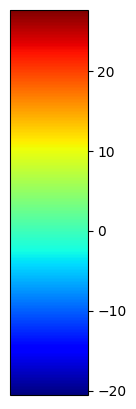

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots(figsize=(1, 5))
norm = plt.Normalize(vmin=-20.550, vmax=27.670)
cb = plt.colorbar(cm.ScalarMappable(norm=norm, cmap='jet'), cax=ax)
# ticklable off
#cb.set_ticklabels([])

#plt.savefig('Figures/pymol_colorbar.pdf', bbox_inches='tight', transparent=True)

# 6. Cosine Similarity Heatmaps

Contact-map-style N×N cosine-similarity matrices.  
The red dashed line marks the receptor/ligand boundary.  
Off-diagonal blocks show cross-chain similarity.

In [13]:
found

['1cmi',
 '1p22',
 '1us7',
 '1vz6',
 '1wm0',
 '2g47',
 '2uzi',
 '2vn5',
 '3dmy',
 '3e2u',
 '3ong',
 '4bi8',
 '4r1h',
 '4z27',
 '5c6d',
 '5c7j',
 '5cer',
 '5h2w',
 '5w1m',
 '5wsv',
 '6a9x',
 '6gum',
 '6iqj',
 '6isc',
 '6lqo',
 '6qev',
 '7tre']

In [14]:
ind = found.index('6isc')

In [15]:
PLOT_PDB = found[ind]

In [16]:
HEATMAP_PDB = PLOT_PDB
CONTACT_CUTOFF = 15.0  # Angstroms — adjustable distance cutoff for contact definition

# Compute real contact map
contact_map, n_rec_contact = compute_contact_map(sthg_dict[HEATMAP_PDB], distance_cutoff=CONTACT_CUTOFF)
# Trained cosine similarity
sim, n_rec = cosine_similarity_matrix(emb_trained, HEATMAP_PDB)

### Demo

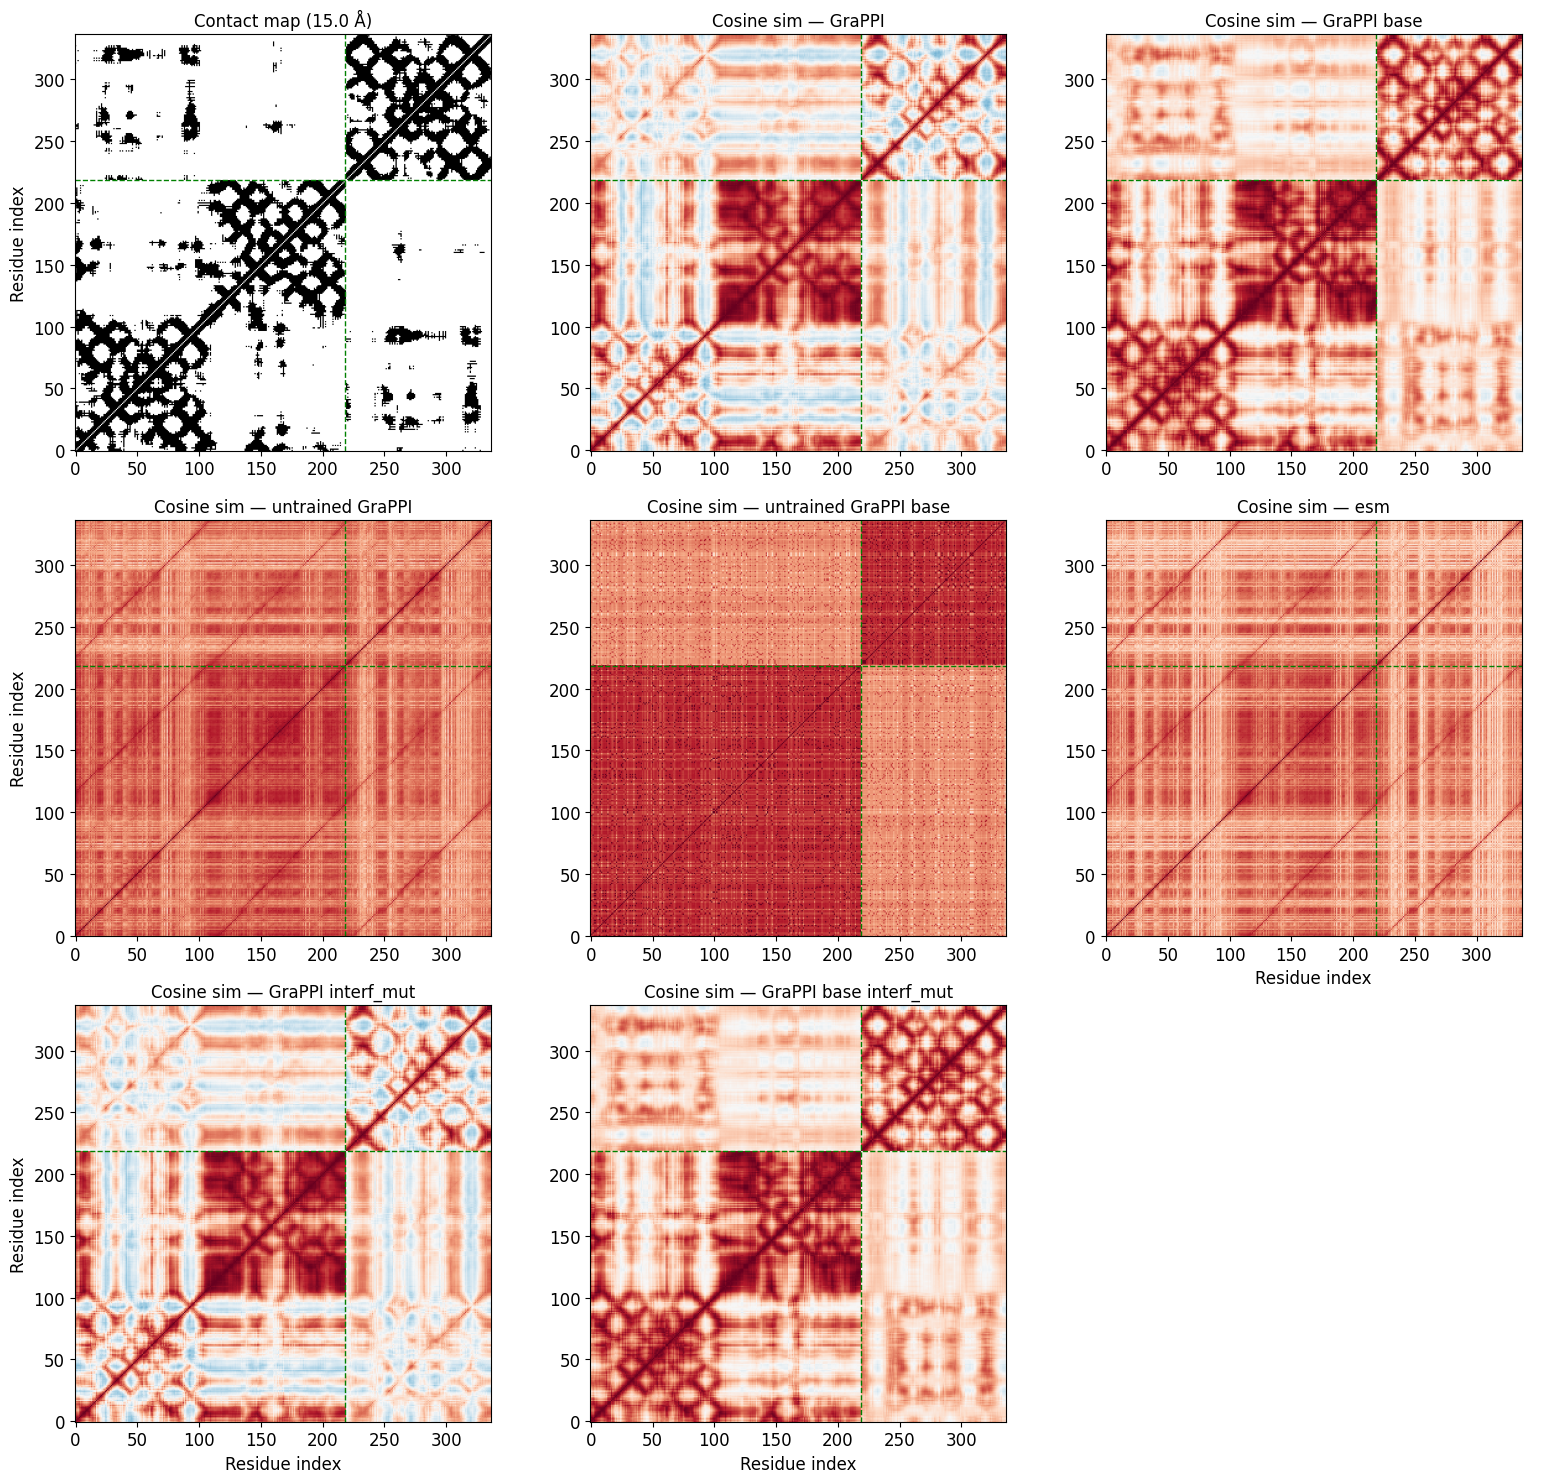

In [17]:
# ── Contact map + cosine similarity for all conditions (3 rows × 3 cols) ──
# Row 0: contact map, GraPPI, GraPPI base
# Row 1: untrained GraPPI, untrained GraPPI base, esm
# Row 2: GraPPI interf_mut, GraPPI base interf_mut, (blank)
fig, axes = plt.subplots(3, 3, figsize=(16, 15))
label_fontsize = 12

sim_grappi, n_rec        = cosine_similarity_matrix(emb_trained,        HEATMAP_PDB)
sim_base, _              = cosine_similarity_matrix(emb_base,           HEATMAP_PDB)
sim_untrained, _         = cosine_similarity_matrix(emb_untrained,      HEATMAP_PDB)
sim_untrained_base, _    = cosine_similarity_matrix(emb_untrained_base, HEATMAP_PDB)
sim_esm, _               = cosine_similarity_matrix(extra_embs['esm'],  HEATMAP_PDB)
sim_mut, n_rec_mut       = cosine_similarity_matrix(emb_mut,            HEATMAP_PDB)
sim_mut_base, _          = cosine_similarity_matrix(emb_mut_base,       HEATMAP_PDB)

# Contact map (no colorbar — values are only 0 or 1)
ax = axes[0, 0]
ax.imshow(contact_map, cmap='Greys', vmin=0, vmax=1, origin='upper')
ax.axhline(n_rec_contact - 0.5, color='green', ls='--', lw=1)
ax.axvline(n_rec_contact - 0.5, color='green', ls='--', lw=1)
ax.set_title(f'Contact map ({CONTACT_CUTOFF} Å)', fontsize=label_fontsize)
ax.set_ylabel('Residue index', fontsize=label_fontsize)
ax.invert_yaxis()

# (axes, similarity matrix, title, receptor-boundary, draw x-label, draw y-label)
cos_panels = [
    (axes[0, 1], sim_grappi,         'GraPPI',                 n_rec,     False, False),
    (axes[0, 2], sim_base,           'GraPPI base',            n_rec,     False, False),
    (axes[1, 0], sim_untrained,      'untrained GraPPI',       n_rec,     False, True),
    (axes[1, 1], sim_untrained_base, 'untrained GraPPI base',  n_rec,     False, False),
    (axes[1, 2], sim_esm,            'esm',                    n_rec,     True,  False),
    (axes[2, 0], sim_mut,            'GraPPI interf_mut',      n_rec_mut, True,  True),
    (axes[2, 1], sim_mut_base,       'GraPPI base interf_mut', n_rec_mut, True,  False),
]
im_cos = None
for ax, mat, title, n_boundary, show_x, show_y in cos_panels:
    im_cos = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1, origin='upper')
    ax.axhline(n_boundary - 0.5, color='green', ls='--', lw=1)
    ax.axvline(n_boundary - 0.5, color='green', ls='--', lw=1)
    ax.set_title(f'Cosine sim — {title}', fontsize=label_fontsize)
    if show_x:
        ax.set_xlabel('Residue index', fontsize=label_fontsize)
    if show_y:
        ax.set_ylabel('Residue index', fontsize=label_fontsize)
    ax.invert_yaxis()

# Last slot is empty
axes[2, 2].axis('off')

plt.tight_layout()
plt.savefig('Figures/contact_map_cosine_similarity.pdf', bbox_inches='tight', format='pdf')


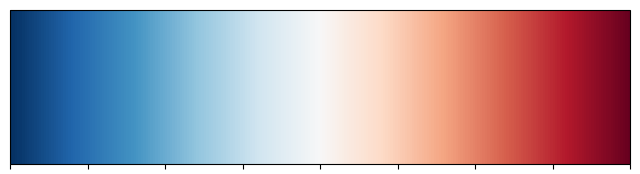

In [27]:
import matplotlib as mpl
import matplotlib.colors as mcolors

fig_cb, axes_cb = plt.subplots(1, 1, figsize=(8, 2))
fig_cb.subplots_adjust(hspace=1.0)

cbar_specs = [
    (axes_cb, 'RdBu_r', mcolors.Normalize(-1, 1),  'Cosine similarity'),
]
for ax, cmap, norm, label in cbar_specs:
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cb = fig_cb.colorbar(sm, cax=ax, orientation='horizontal')
    #cb.set_label(label, fontsize=10)
# remove ticklabels
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.savefig('Figures/contact_cos_sim_heatmap_cbs.pdf', bbox_inches='tight', dpi=220)

# 7. 2-D Embedding Scatter (UMAP / t-SNE)

Per-residue embeddings projected to 2-D, coloured by chain type and
interface membership.

In [ ]:
SCATTER_PDB    = PLOT_PDB
SCATTER_METHOD = 'pca'  # 'umap' or 'tsne' or 'pca'

# Pick which embeddings to visualise (single-condition scatter):
#   'GraPPI' | 'GraPPI base' | 'untrained GraPPI' | 'untrained GraPPI base'
#   | 'esm' | 'GraPPI interf_mut' | 'GraPPI base interf_mut'
data_key_word = 'esm'

scatter_emb_map = {
    'GraPPI':                 emb_trained,
    'GraPPI base':            emb_base,
    'untrained GraPPI':       emb_untrained,
    'untrained GraPPI base':  emb_untrained_base,
    'GraPPI interf_mut':      emb_mut,
    'GraPPI base interf_mut': emb_mut_base,
}
for lbl, emb_d in extra_embs.items():
    scatter_emb_map[lbl] = emb_d   # adds 'esm'

emb_sel = scatter_emb_map[data_key_word]

# Interface mask: use the mutant graph for interf_mut conditions, else the WT graph
sthg_for_mask = sthg_dict_mut if data_key_word.endswith('interf_mut') else sthg_dict
rec_mask_s, lig_mask_s = get_interface_mask(sthg_for_mask[SCATTER_PDB])
full_mask_s = np.concatenate([rec_mask_s, lig_mask_s])

coords, n_rec = embed_2d(emb_sel, SCATTER_PDB, method=SCATTER_METHOD)
print(f'{data_key_word}: {coords.shape}')


esm: (337, 2)


## Demo — single-condition scatter (select via `data_key_word`)

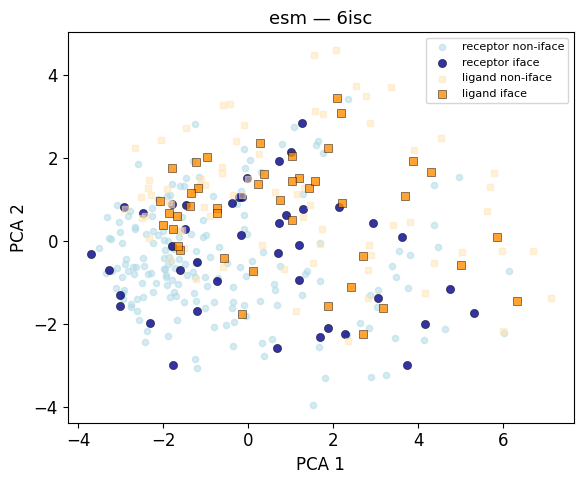

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))

chain = np.array(['receptor'] * n_rec + ['ligand'] * (len(coords) - n_rec))
iface = full_mask_s

for ct, base_c, iface_c, marker in [
    ('receptor', 'lightblue', 'darkblue', 'o'),
    ('ligand',   'moccasin',  'darkorange', 's'),
]:
    ct_mask = chain == ct
    non_if = ct_mask & ~iface
    is_if  = ct_mask & iface
    ax.scatter(coords[non_if, 0], coords[non_if, 1],
               c=base_c, marker=marker, s=20, alpha=0.5,
               label=f'{ct} non-iface')
    ax.scatter(coords[is_if, 0], coords[is_if, 1],
               c=iface_c, marker=marker, s=35, alpha=0.8, edgecolors='black', linewidths=0.4,
               label=f'{ct} iface')

ax.set_title(f'{data_key_word} — {SCATTER_PDB}', fontsize=13)
ax.set_xlabel(f'{SCATTER_METHOD.upper()} 1')
ax.set_ylabel(f'{SCATTER_METHOD.upper()} 2')
ax.legend(fontsize=8, loc='best')

plt.tight_layout()


## Formal

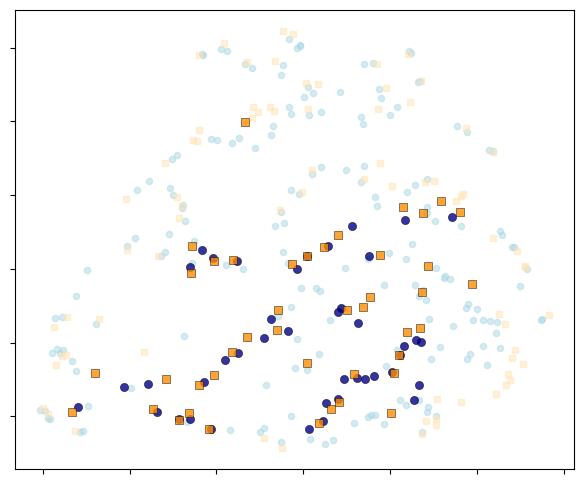

In [54]:
fig, ax = plt.subplots(figsize=(6, 5))

chain = np.array(['receptor'] * n_rec + ['ligand'] * (len(coords) - n_rec))
iface = full_mask_s

for ct, base_c, iface_c, marker in [
    ('receptor', 'lightblue', 'darkblue', 'o'),
    ('ligand',   'moccasin',  'darkorange', 's'),
]:
    ct_mask = chain == ct
    non_if = ct_mask & ~iface
    is_if  = ct_mask & iface
    ax.scatter(coords[non_if, 0], coords[non_if, 1],
               c=base_c, marker=marker, s=20, alpha=0.5,
               label=f'{ct} non-iface')
    ax.scatter(coords[is_if, 0], coords[is_if, 1],
               c=iface_c, marker=marker, s=35, alpha=0.8, edgecolors='black', linewidths=0.4,
               label=f'{ct} iface')
# turn off axis ticklabels
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(f"Figures/{SCATTER_PDB}_{SCATTER_METHOD}_{data_key_word.replace(' ', '_')}_scatter.pdf",
            bbox_inches='tight', dpi=220)


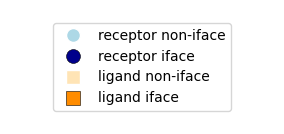

In [30]:
# print legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',  markersize=10, label='receptor non-iface'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkblue',   markersize=10, label='receptor iface',
           markeredgecolor='black', markeredgewidth=0.4),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='moccasin',   markersize=10, label='ligand non-iface'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='darkorange', markersize=10, label='ligand iface',
           markeredgecolor='black', markeredgewidth=0.4),
]

fig_leg, ax_leg = plt.subplots(figsize=(3, 1.5))
ax_leg.axis('off')
ax_leg.legend(handles=legend_elements, loc='center', fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig(f'./Figures/{SCATTER_PDB}_{SCATTER_METHOD}_scatter_legend.pdf', dpi=220, bbox_inches='tight')

# 8. Attention Score Extraction & Visualisation

Extract attention weights from the **last HGT layer** of the trained encoder
using monkey-patching (safe — uses a deep copy).

Includes:
- Per-node total attention line plot
- Per-edge-type attention histograms
- Top-*k* attended residues table

In [19]:
# Choose which model's attention to inspect:
#   True  → 6layers_10hdim_esm (GraPPI, ESM features)  — used for main text
#   False → 6layers_10hdim      (GraPPI base)          — used for SI
ATTN_USE_ESM = True
SCATTER_PDB  = PLOT_PDB

attn_path   = PRETRAINED_PATH if ATTN_USE_ESM else BASE_PRETRAINED_PATH
attn_config = ssl_config      if ATTN_USE_ESM else ssl_config_base
attn_sthg   = sthg_dict       if ATTN_USE_ESM else sthg_dict_base
attn_tag    = 'GraPPI'        if ATTN_USE_ESM else 'GraPPI_base'

# Build & load the chosen encoder
attn_encoder = build_encoder(attn_config, device)
ckpt = torch.load(os.path.join(attn_path, 'ssl_edge_best.pt'), map_location='cpu')
attn_encoder.load_state_dict(ckpt['encoder_state_dict'])
attn_encoder.eval()
print(f'Attention model: {attn_tag} ({attn_path})')


Attention model: GraPPI (/mnt/boltzmann/data/zhisong/trained_data_ssl_finetune/6layers_10hdim_esm/)


In [20]:
ATTN_PDB = '6isc'
all_layer_attn = extract_attention_scores(attn_encoder, attn_sthg[ATTN_PDB],
                                          device=device, all_layers=True)


Choose the last layer of HGT

In [21]:
node_attention = all_layer_attn[5]['node_attention']

In [22]:
# Build per-residue DataFrame from AA_df
sthg = attn_sthg[ATTN_PDB]
aa = sthg.AA_df
rec_mask, lig_mask = get_interface_mask(sthg)
full_iface = np.concatenate([rec_mask, lig_mask])

res_df = pd.DataFrame({
    'residue_index': range(1, len(aa)+1),
    'res_name':      aa['res_name'].values,
    'res_letter':    aa['res_letter'].values,
    'chain_type':    aa['chain_type'].values,
    'if_interface':  full_iface,
})

# Add attention columns
for col in ['attention_total', 'attention_incoming', 'attention_outgoing']:
    res_df[col] = None

for chain_type in ('receptor', 'ligand'):
    mask = res_df['chain_type'] == chain_type
    res_df.loc[mask, 'attention_total']    = node_attention[chain_type]['total'].cpu().numpy().tolist()
    res_df.loc[mask, 'attention_incoming'] = node_attention[chain_type]['incoming'].cpu().numpy().tolist()
    res_df.loc[mask, 'attention_outgoing'] = node_attention[chain_type]['outgoing'].cpu().numpy().tolist()

print(f'Top 20 residues by total attention (PDB: {ATTN_PDB}, model: {attn_tag}):')
res_df_num = res_df.copy()
res_df_num['attention_total'] = pd.to_numeric(res_df_num['attention_total'], errors='coerce')
display(res_df_num.nlargest(30, 'attention_total')[
    ['res_name', 'res_letter', 'chain_type', 'if_interface',
     'attention_total']])


Top 20 residues by total attention (PDB: 6isc, model: GraPPI):


,res_name,res_letter,chain_type,if_interface,attention_total
257,TRP,W,ligand,True,4.784102
138,GLN,Q,receptor,False,4.523302
169,ARG,R,receptor,False,4.508624
28,TRP,W,receptor,True,4.377108
259,ARG,R,ligand,True,3.977498
163,TYR,Y,receptor,True,3.917154
324,ARG,R,ligand,True,3.737136
98,GLU,E,receptor,True,3.702157
161,THR,T,receptor,True,3.606211
23,LEU,L,receptor,True,3.410577


In [23]:
res_df_num[['residue_index','res_name','res_letter','if_interface','attention_total']].to_csv(f'result_csv_data/{SCATTER_PDB}_attention.csv')

In [26]:
demo_df = res_df_num[['residue_index','res_name','res_letter','if_interface','attention_total']].nlargest(30, 'attention_total')
demo_df.sort_values(by='residue_index', ascending=True)

,residue_index,res_name,res_letter,if_interface,attention_total
23,24,LEU,L,True,3.410577
28,29,TRP,W,True,4.377108
30,31,LYS,K,False,3.175202
39,40,ILE,I,True,2.961765
42,43,TYR,Y,True,3.391134
50,51,ILE,I,True,3.003657
84,85,ILE,I,False,2.975197
85,86,TYR,Y,False,2.859781
88,89,LEU,L,True,3.105411
97,98,TRP,W,True,3.253314


## Demo

Interface residues in top 30: 18 (60%)


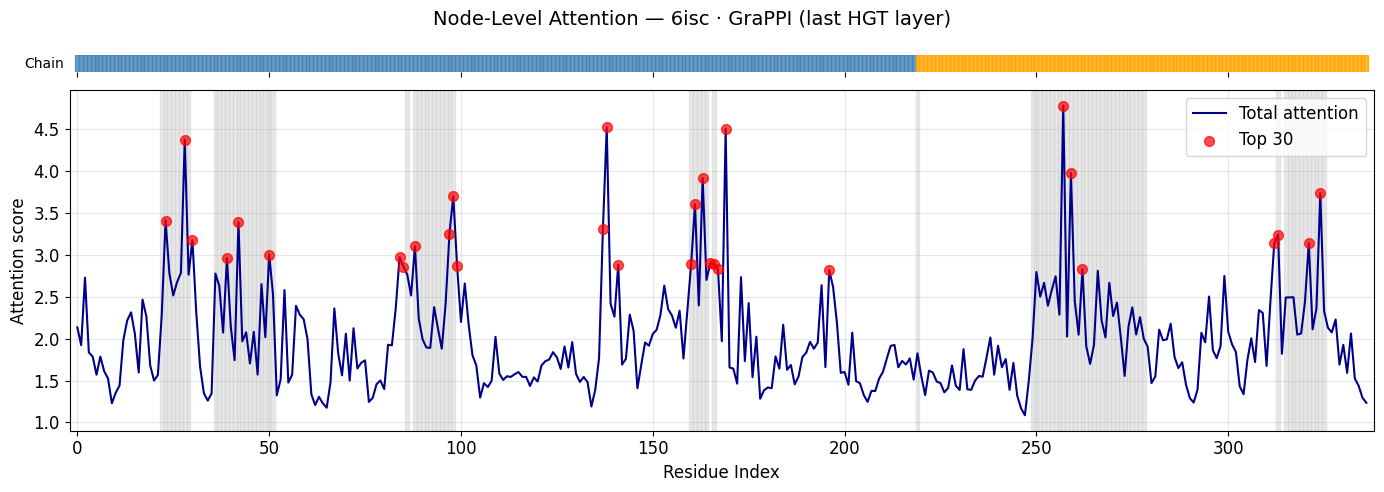

In [73]:
# ── Node-level attention line plot ────────────────────────────────────
TOP_X = 30

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True,
                         gridspec_kw={'height_ratios': [0.05, 1]})

ax_bar = axes[0]
for _, row in res_df.iterrows():
    c = 'steelblue' if row['chain_type'] == 'receptor' else 'orange'
    ax_bar.axvspan(row['residue_index'] - 0.5, row['residue_index'] + 0.5,
                   color=c, alpha=0.8)
ax_bar.set_ylim(0, 1); ax_bar.set_yticks([])
ax_bar.set_ylabel('Chain', fontsize=10, rotation=0, ha='right', va='center')
for sp in ax_bar.spines.values(): sp.set_visible(False)

ax = axes[1]
ax.plot(res_df['residue_index'], res_df_num['attention_total'],
        lw=1.5, color='darkblue', label='Total attention')
for _, r in res_df[res_df['if_interface']].iterrows():
    ax.axvspan(r['residue_index'] - 0.5, r['residue_index'] + 0.5,
               color='lightgrey', alpha=0.5, zorder=0)
top_res = res_df_num.nlargest(TOP_X, 'attention_total')
ax.scatter(top_res['residue_index'], top_res['attention_total'],
           color='red', s=50, zorder=5, alpha=0.7, label=f'Top {TOP_X}')
ax.set_ylabel('Attention score')
ax.set_xlabel('Residue Index')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
fig.suptitle(f'Node-Level Attention — {ATTN_PDB} · {attn_tag} (last HGT layer)', fontsize=14, y=0.98)
ax.set_xlim(res_df['residue_index'].min() - 2, res_df['residue_index'].max() + 2)
plt.tight_layout()

iface_in_top = top_res['if_interface'].sum()
print(f'Interface residues in top {TOP_X}: {iface_in_top} '
      f'({iface_in_top/TOP_X*100:.0f}%)')

## Formal

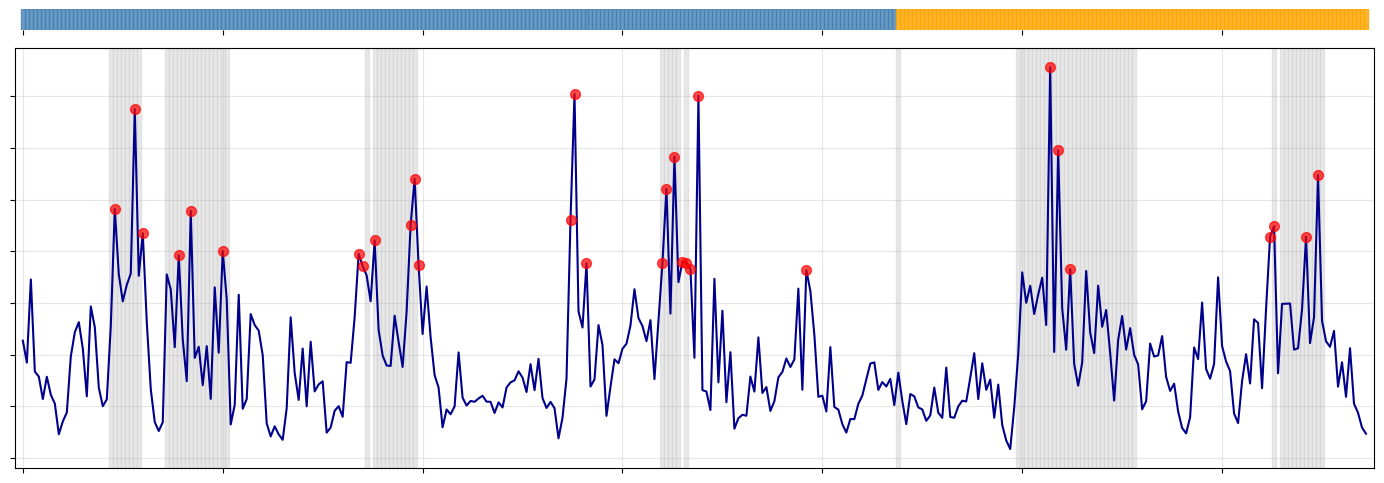

In [74]:
# ── Node-level attention line plot ────────────────────────────────────
TOP_X = 30

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True,
                         gridspec_kw={'height_ratios': [0.05, 1]})

ax_bar = axes[0]
for _, row in res_df.iterrows():
    c = 'steelblue' if row['chain_type'] == 'receptor' else 'orange'
    ax_bar.axvspan(row['residue_index'] - 0.5, row['residue_index'] + 0.5,
                   color=c, alpha=0.8)
ax_bar.set_ylim(0, 1); ax_bar.set_yticks([])
for sp in ax_bar.spines.values(): sp.set_visible(False)

ax = axes[1]
ax.plot(res_df['residue_index'], res_df_num['attention_total'],
        lw=1.5, color='darkblue', label='Total attention')
for _, r in res_df[res_df['if_interface']].iterrows():
    ax.axvspan(r['residue_index'] - 0.5, r['residue_index'] + 0.5,
               color='lightgrey', alpha=0.5, zorder=0)
top_res = res_df_num.nlargest(TOP_X, 'attention_total')
ax.scatter(top_res['residue_index'], top_res['attention_total'],
           color='red', s=50, zorder=5, alpha=0.7, label=f'Top {TOP_X}')
ax.set_xlim(res_df['residue_index'].min() - 2, res_df['residue_index'].max() + 2)
ax.grid(True, alpha=0.3)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(f'./Figures/{ATTN_PDB}_{attn_tag}_Last_layer_attn_score.pdf', dpi=220, format='pdf')

# Attention score for other layers SI

Layer 0 — Interface residues in top 30: 13 (43%)
Layer 1 — Interface residues in top 30: 11 (37%)
Layer 2 — Interface residues in top 30: 18 (60%)
Layer 3 — Interface residues in top 30: 21 (70%)
Layer 4 — Interface residues in top 30: 14 (47%)


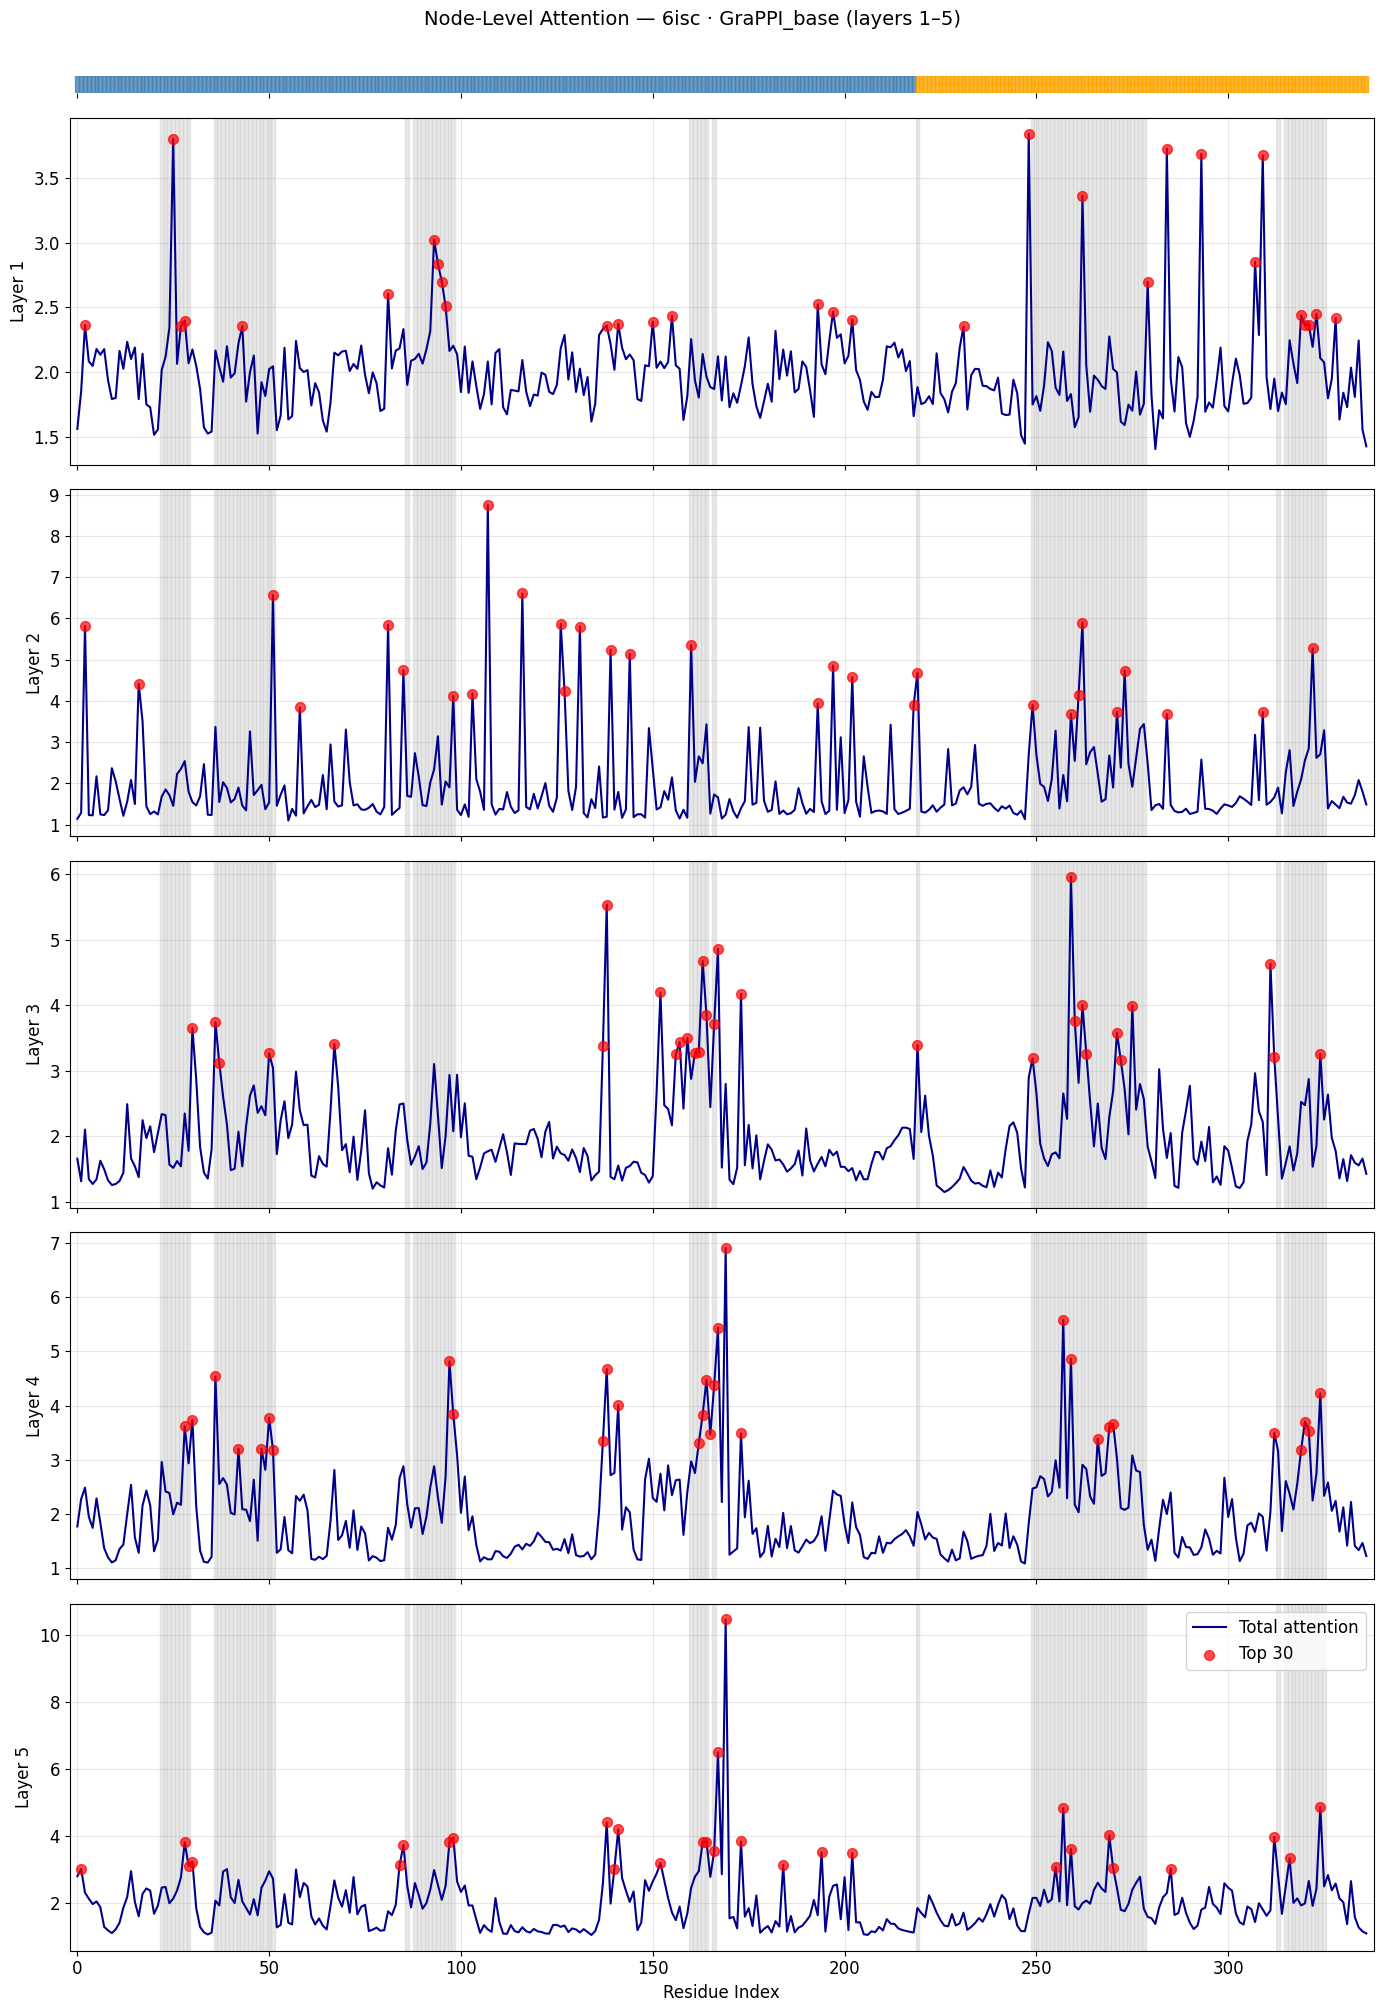

In [68]:
TOP_X = 30
n_layers = len(all_layer_attn)

fig, axes = plt.subplots(
    n_layers, 1, figsize=(14, 4 * (n_layers-1)), sharex=True,
    gridspec_kw={'height_ratios': [0.05] + [1] * (n_layers-1)},
)

# ── Top bar: chain colour band ─────────────────────────────────────────
ax_bar = axes[0]
for _, row in res_df.iterrows():
    c = 'steelblue' if row['chain_type'] == 'receptor' else 'orange'
    ax_bar.axvspan(row['residue_index'] - 0.5, row['residue_index'] + 0.5,
                   color=c, alpha=0.8)
ax_bar.set_ylim(0, 1)
ax_bar.set_yticks([])
#ax_bar.set_ylabel('Chain', fontsize=10, rotation=0, ha='right', va='center')
for sp in ax_bar.spines.values():
    sp.set_visible(False)

# ── One subplot per HGT layer ──────────────────────────────────────────
for idx in range(n_layers-1):
    node_attention = all_layer_attn[idx]['node_attention']

    layer_df = pd.DataFrame({
        'residue_index': range(len(aa)),
        'res_name':      aa['res_name'].values,
        'res_letter':    aa['res_letter'].values,
        'chain_type':    aa['chain_type'].values,
        'if_interface':  full_iface,
    })
    for col in ['attention_total', 'attention_incoming', 'attention_outgoing']:
        layer_df[col] = None
    for chain_type in ('receptor', 'ligand'):
        mask = layer_df['chain_type'] == chain_type
        layer_df.loc[mask, 'attention_total']    = node_attention[chain_type]['total'].cpu().numpy().tolist()
        layer_df.loc[mask, 'attention_incoming'] = node_attention[chain_type]['incoming'].cpu().numpy().tolist()
        layer_df.loc[mask, 'attention_outgoing'] = node_attention[chain_type]['outgoing'].cpu().numpy().tolist()

    layer_df_num = layer_df.copy()
    layer_df_num['attention_total'] = pd.to_numeric(layer_df_num['attention_total'], errors='coerce')

    ax = axes[idx + 1]
    ax.plot(layer_df['residue_index'], layer_df_num['attention_total'],
            lw=1.5, color='darkblue', label='Total attention')
    for _, r in layer_df[layer_df['if_interface']].iterrows():
        ax.axvspan(r['residue_index'] - 0.5, r['residue_index'] + 0.5,
                   color='lightgrey', alpha=0.5, zorder=0)
    top_res = layer_df_num.nlargest(TOP_X, 'attention_total')
    ax.scatter(top_res['residue_index'], top_res['attention_total'],
               color='red', s=50, zorder=5, alpha=0.7, label=f'Top {TOP_X}')
    ax.set_ylabel(f'Layer {idx+1}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(layer_df['residue_index'].min() - 2, layer_df['residue_index'].max() + 2)

    iface_in_top = top_res['if_interface'].sum()
    print(f'Layer {idx} — Interface residues in top {TOP_X}: {iface_in_top} '
          f'({iface_in_top / TOP_X * 100:.0f}%)')

axes[-1].set_xlabel('Residue Index',)
axes[-1].legend(loc='upper right')
fig.suptitle(f'Node-Level Attention — {ATTN_PDB} · {attn_tag} (layers 1–{n_layers - 1})',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(f'./Figures/{ATTN_PDB}_{attn_tag}_other_layers_attn_score.pdf', dpi=220, format='pdf')